# Week 3 Homework: Encoder vs Decoder — The Full Comparison

**ECBS5200 — Practical Deep Learning Engineering**

In the lab you trained an encoder with LoRA and loaded a pre-trained decoder.
The decoder won on macro F1. But you didn't train the decoder yourself, and
you didn't try to improve it.

Now you will. This notebook has you:
1. Train the decoder from scratch with LoRA (or load the pre-trained checkpoint)
2. Apply class weighting to the decoder (did it help the encoder in Week 2?)
3. Benchmark latency for both architectures
4. Write your memo: given these results, what would you deploy?

**Expected time:** ~4-5 hours on a Kaggle T4 GPU.
Decoder training takes ~59 min per run. Plan accordingly.

**Point breakdown:** 20 / 20 / 25 / 20 / 15 across the five memo sections.
See Part 8 for details. Budget your time accordingly — the per-class analysis
and deployment question carry the most weight.

**How to use this notebook:**
- **GUIDED** cells run as-is. Read them.
- **INTERACTIVE** cells require you to fill in values or write answers.
- `___` is a placeholder that will cause a NameError if not filled in.
- The last section is your memo draft.

## Kaggle setup

1. **Persistence** → "Variables and Files"
2. **Internet** → On
3. **Accelerator** → GPU T4

In [11]:
import subprocess, sys, os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# HuggingFace config — set BEFORE importing HF libraries
if os.path.exists('/kaggle/working'):
    os.environ['HF_HOME'] = '/kaggle/working/.hf_cache'
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '120'
os.environ['HF_HUB_ETAG_TIMEOUT'] = '60'
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '0'

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet",
    "transformers>=4.53", "datasets", "accelerate", "scikit-learn",
    "matplotlib", "pandas", "tqdm", "peft", "torchao>=0.16.0"
])
print("Packages installed.")

from huggingface_hub import login
hf_token = None
try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    pass
if not hf_token:
    try:
        from google.colab import userdata
        hf_token = userdata.get("HF_TOKEN")
    except Exception:
        pass
if not hf_token:
    hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
if hf_token:
    login(token=hf_token)
    print("Logged in to HuggingFace.")
else:
    print("WARNING: No HF_TOKEN found.")

Packages installed.
Logged in to HuggingFace.


In [2]:
import gc
import time
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Load course utilities
REPO_PATH = Path("../..").resolve()
if not (REPO_PATH / "utils" / "data_utils.py").exists():
    REPO_PATH = Path("/tmp/course")
    if not REPO_PATH.exists():
        subprocess.check_call(["git", "clone", "--depth", "1",
            "https://github.com/earino/applied-deep-learning.git", str(REPO_PATH)])
sys.path.insert(0, str(REPO_PATH))

from utils.data_utils import (
    load_course_data, LABEL_LIST, NUM_LABELS, LABEL_TO_ID, ID_TO_LABEL, MAX_LENGTH,
)

In [3]:
# Reproducibility and device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    cc = torch.cuda.get_device_capability()
    USE_BF16 = cc[0] >= 8
    USE_FP16 = not USE_BF16
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Precision: {'bf16' if USE_BF16 else 'fp16'}")
else:
    USE_BF16, USE_FP16 = False, False
    print("No GPU detected.")

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Precision: bf16


---
## Part 1: Data and Lab Results (~10 min)
---

In [4]:
# GUIDED: Load the canonical dataset
print("Loading dataset...")
train_ds, val_ds, _ = load_course_data()
print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}  Classes: {NUM_LABELS}")

# Class distribution
label_counts = Counter(train_ds["label"])
sorted_counts = sorted(label_counts.values())
q25 = sorted_counts[len(sorted_counts) // 4]
rare_ids = sorted([lid for lid, c in label_counts.items() if c <= q25])
common_ids = sorted([lid for lid in label_counts if lid not in set(rare_ids)])

print(f"Rare classes (count <= {q25}): {len(rare_ids)}")
print(f"Common classes: {len(common_ids)}")

Loading dataset...


README.md:   0%|          | 0.00/606 [00:00<?, ?B/s]

data/train-00000-of-00001-f6ccf6490f1232(…):   0%|          | 0.00/10.2M [00:00<?, ?B/s]

data/test-00000-of-00001-0b18a4667c07409(…):   0%|          | 0.00/3.39M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/64292 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/6430 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6430 [00:00<?, ? examples/s]

Map:   0%|          | 0/21439 [00:00<?, ? examples/s]

Filter:   0%|          | 0/21439 [00:00<?, ? examples/s]

Train: 57,846  Val: 6,430  Classes: 113
Rare classes (count <= 27): 29
Common classes: 84


In [41]:
# GUIDED: Load your lab results (encoder LoRA metrics from the lab)
lab_results_path = Path("week3_lab_results.json")
if lab_results_path.exists():
    with open(lab_results_path) as f:
        lab_results = json.load(f)
    enc_f1_lab = lab_results["encoder_lora"]["macro_f1"]
    enc_acc_lab = lab_results["encoder_lora"]["accuracy"]
    enc_zero_lab = lab_results["encoder_lora"]["zero_f1_classes"]
    enc_per_class_f1 = np.array(lab_results["encoder_lora"]["per_class_f1"])
    print(f"Lab encoder LoRA: acc={enc_acc_lab:.1%}, F1={enc_f1_lab:.4f}, zero-F1={enc_zero_lab}")
else:
    print("WARNING: week3_lab_results.json not found.")
    print("Re-run the lab notebook or enter your encoder results manually below.")
    enc_acc_lab = 0.569       # Your encoder LoRA accuracy from lab
    enc_f1_lab = 0.2211        # Your encoder LoRA macro F1 from lab
    enc_zero_lab = 45      # Your encoder LoRA zero-F1 count from lab
    enc_per_class_f1 = None

Re-run the lab notebook or enter your encoder results manually below.


---
## Part 2: Train the Decoder (~60 min)

In the lab you loaded a pre-trained decoder. Now build and train one yourself.

The model is Qwen2.5-0.5B — a **decoder** (causal language model) with 494M
parameters. You'll use `AutoModelForSequenceClassification` with a LoRA adapter,
just like you did with the encoder, but there are architectural differences
you need to handle.
---

In [6]:
# GUIDED: Load tokenizer — decoders need LEFT padding
DEC_MODEL = "Qwen/Qwen2.5-0.5B"

dec_tokenizer = AutoTokenizer.from_pretrained(DEC_MODEL)
dec_tokenizer.padding_side = "left"   # Causal LMs classify the LAST token
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

print(f"Tokenizer: {DEC_MODEL}")
print(f"Padding side: {dec_tokenizer.padding_side}")
print(f"Pad token: '{dec_tokenizer.pad_token}'")

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: Qwen/Qwen2.5-0.5B
Padding side: left
Pad token: '<|endoftext|>'


### Why left padding?

Decoders read left-to-right. The classification head takes the hidden state
of the **last non-padding token**. If you right-pad (the encoder default),
the last token is always `<pad>` — the model classifies padding, not text.
Left padding pushes the real content to the right edge where the classifier
reads it.

In [7]:
# GUIDED: Tokenize
def tokenize_fn(batch):
    return dec_tokenizer(
        batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False,
    )

print("Tokenizing...")
dec_train = train_ds.map(tokenize_fn, batched=True, remove_columns=["text", "label_name"])
dec_val = val_ds.map(tokenize_fn, batched=True, remove_columns=["text", "label_name"])
dec_train = dec_train.rename_column("label", "labels")
dec_val = dec_val.rename_column("label", "labels")
print(f"  Train: {len(dec_train):,}  Val: {len(dec_val):,}")

Tokenizing...


Map:   0%|          | 0/57846 [00:00<?, ? examples/s]

Map:   0%|          | 0/6430 [00:00<?, ? examples/s]

  Train: 57,846  Val: 6,430


### INTERACTIVE: Load the model and configure LoRA

This is a decoder, not an encoder. Two things are different:

1. **Loading:** The model must be loaded in `float32`. Qwen defaults to bfloat16,
   but T4 can't handle bfloat16 GradScaler operations. Load in float32 and let
   the Trainer handle mixed precision.

2. **LoRA config:** You need `modules_to_save=["score"]`. The classification head
   (`score` layer) is randomly initialized. Without saving it, the adapter
   checkpoint would reload with a fresh random head — your training would be lost.

Run the cell below to see the decoder's layer names, then configure LoRA.

In [8]:
# GUIDED: Load model
print(f"Loading {DEC_MODEL}...")
decoder = AutoModelForSequenceClassification.from_pretrained(
    DEC_MODEL,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID,
    dtype=torch.float32,
)
decoder.config.pad_token_id = dec_tokenizer.pad_token_id
decoder = decoder.to(device)

print(f"Parameters: {sum(p.numel() for p in decoder.parameters()):,}")

Loading Qwen/Qwen2.5-0.5B...


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 494,134,016


In [9]:
# GUIDED: Explore the decoder's layer names
for name, module in decoder.named_modules():
    if hasattr(module, "weight") and module.weight.dim() >= 2:
        shape = tuple(module.weight.shape)
        print(f"  {name:<55} {str(shape):>15}")

  model.embed_tokens                                        (151936, 896)
  model.layers.0.self_attn.q_proj                              (896, 896)
  model.layers.0.self_attn.k_proj                              (128, 896)
  model.layers.0.self_attn.v_proj                              (128, 896)
  model.layers.0.self_attn.o_proj                              (896, 896)
  model.layers.0.mlp.gate_proj                                (4864, 896)
  model.layers.0.mlp.up_proj                                  (4864, 896)
  model.layers.0.mlp.down_proj                                (896, 4864)
  model.layers.1.self_attn.q_proj                              (896, 896)
  model.layers.1.self_attn.k_proj                              (128, 896)
  model.layers.1.self_attn.v_proj                              (128, 896)
  model.layers.1.self_attn.o_proj                              (896, 896)
  model.layers.1.mlp.gate_proj                                (4864, 896)
  model.layers.1.mlp.up_proj          

Notice the differences from ModernBERT:
- Attention layers are `q_proj`, `k_proj`, `v_proj`, `o_proj` (separate projections,
  not a fused `Wqkv`)
- Feed-forward layers are `gate_proj`, `up_proj`, `down_proj` (SwiGLU, not standard MLP)
- There's a `score` layer at the end — that's the classification head

In [12]:
# INTERACTIVE: Configure LoRA for the decoder.
# Target the attention projections. Include modules_to_save=["score"].

dec_lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"], # Which attention modules from the list above?
    modules_to_save=["score"],   # MUST include this — saves the classification head
    task_type="SEQ_CLS",
)

decoder = get_peft_model(decoder, dec_lora_config)

total_p = sum(p.numel() for p in decoder.parameters())
train_p = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"Total: {total_p:,}  Trainable: {train_p:,} ({100*train_p/total_p:.2f}%)")

Total: 496,397,952  Trainable: 2,263,936 (0.46%)


In [13]:
# GUIDED: Shared training components
dec_collator = DataCollatorWithPadding(tokenizer=dec_tokenizer, padding=True,
                                       pad_to_multiple_of=8)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    per_class = f1_score(labels, preds, average=None, zero_division=0,
                         labels=list(range(NUM_LABELS)))
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, preds, average="weighted", zero_division=0),
        "zero_f1_classes": int(sum(1 for f in per_class if f == 0.0)),
    }

### Experiment 1: Decoder LoRA vanilla (~59 min)

Train the decoder with standard cross-entropy loss. No class weighting.

**Time choice:** Training takes ~59 minutes. If you want to save an hour
for the class weighting experiment and analysis, set `SKIP_VANILLA_TRAINING = True`
below to load the pre-trained decoder instead. You'll still configure LoRA
(Part 2 above) and evaluate — you just skip the training loop.

```
EXPERIMENT: Decoder LoRA vanilla
──────────────────
Variable changed:  [architecture — decoder instead of encoder]
Held constant:     [dataset, LoRA rank/alpha, learning rate, batch size, epochs]
```

YOUR PREDICTION:
```
Prediction:        I expect higher macro F1, around 0.225
Result:            After three epochs, it surpassed 0.235
```



In [14]:
SKIP_VANILLA_TRAINING = False  # Set True to load pre-trained instead of training

In [15]:
dec_args_vanilla = TrainingArguments(
    output_dir="dec_vanilla_output",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=100,
    lr_scheduler_type="linear",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=USE_FP16,
    bf16=USE_BF16,
    gradient_checkpointing=False,
    seed=SEED,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
)

dec_trainer_vanilla = Trainer(
    model=decoder,
    args=dec_args_vanilla,
    train_dataset=dec_train,
    eval_dataset=dec_val,
    data_collator=dec_collator,
    compute_metrics=compute_metrics,
)

In [16]:
if not SKIP_VANILLA_TRAINING:
    # Training: ~59 min on T4
    print("Training decoder LoRA (vanilla)...")
    t0 = time.time()
    dec_trainer_vanilla.train()
    dec_vanilla_time = time.time() - t0
    print(f"\nDone in {dec_vanilla_time/60:.1f} min")
else:
    print("Skipping training — loading pre-trained decoder from HuggingFace Hub...")
    del decoder, dec_trainer_vanilla
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    decoder = AutoModelForSequenceClassification.from_pretrained(
        "earino/ecbs5200-week3-decoder-lora",
    ).to(device)
    decoder.eval()

    dec_trainer_vanilla = Trainer(
        model=decoder,
        args=TrainingArguments(output_dir="/tmp/eval", per_device_eval_batch_size=64,
                               report_to="none"),
        data_collator=dec_collator,
        compute_metrics=compute_metrics,
    )
    dec_vanilla_time = 0
    print("Pre-trained decoder loaded.")

Training decoder LoRA (vanilla)...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Zero F1 Classes
1,1.553050,1.653143,0.537792,0.195889,0.505341,52
2,1.390524,1.558717,0.565008,0.212822,0.529862,46
3,1.033200,1.625352,0.569051,0.235644,0.547498,38



Done in 6.7 min


In [17]:
# Evaluate
vanilla_metrics = dec_trainer_vanilla.evaluate(dec_val)
vanilla_preds_out = dec_trainer_vanilla.predict(dec_val)
vanilla_pred_ids = np.argmax(vanilla_preds_out.predictions, axis=-1)
vanilla_true_ids = vanilla_preds_out.label_ids
vanilla_per_class_f1 = f1_score(vanilla_true_ids, vanilla_pred_ids, average=None,
                                 zero_division=0, labels=list(range(NUM_LABELS)))

print(f"\n{'='*50}")
print(f"DECODER LORA VANILLA")
print(f"{'='*50}")
print(f"  Accuracy:  {vanilla_metrics['eval_accuracy']*100:.1f}%")
print(f"  Macro F1:  {vanilla_metrics['eval_macro_f1']:.4f}")
print(f"  Zero-F1:   {vanilla_metrics['eval_zero_f1_classes']}/113")
if dec_vanilla_time > 0:
    print(f"  Time:      {dec_vanilla_time/60:.1f} min")
else:
    print(f"  (loaded pre-trained checkpoint)")


DECODER LORA VANILLA
  Accuracy:  56.9%
  Macro F1:  0.2356
  Zero-F1:   38/113
  Time:      6.7 min


In [18]:
# Clean up for next experiment
del decoder, dec_trainer_vanilla
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Model unloaded.")

Model unloaded.


---
## Part 3: Decoder + Class Weighting (~60 min)

In Week 2, class weighting helped the encoder: accuracy dropped but macro F1
improved by ~15%, and 9 classes went from zero F1 to nonzero.

Will the same trick help the decoder?
---

### INTERACTIVE: Compute class weights

Use the sqrt-inverse formula from Week 2. You've done this before.

In [33]:
# INTERACTIVE: Compute sqrt-inverse class weights
labels_array = np.array(train_ds["label"])
unique_classes = np.arange(NUM_LABELS)

raw_weights = compute_class_weight("balanced", classes=unique_classes, y=labels_array)
sqrt_weights = np.sqrt(raw_weights)  # Apply sqrt to raw_weights
sqrt_weights = sqrt_weights / sqrt_weights.mean()  # Normalize so mean = 1.0

class_weights_tensor = torch.tensor(sqrt_weights, dtype=torch.float32)

print(f"Class weights: min={sqrt_weights.min():.3f}, max={sqrt_weights.max():.3f}, "
      f"mean={sqrt_weights.mean():.3f}")
assert abs(sqrt_weights.mean() - 1.0) < 0.01, "Weights should be normalized to mean=1"

Class weights: min=0.063, max=3.609, mean=1.000


### INTERACTIVE: Build the weighted trainer

The HuggingFace Trainer uses standard cross-entropy by default. To inject
class weights, you need to subclass it and override `compute_loss`.

Fill in the loss function below.

In [34]:
# INTERACTIVE: Complete the WeightedTrainer
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)    # Move class_weights to the same device as logits
        )
        loss = loss_fn(logits, labels)   # What are the two arguments to cross-entropy?
        return (loss, outputs) if return_outputs else loss

### Experiment 2: Decoder LoRA + class weighting (~59 min)

```
EXPERIMENT: Decoder LoRA + sqrt-inverse class weighting
──────────────────
Variable changed:  [loss function — add class weighting]
Held constant:     [model, LoRA config, lr, batch size, epochs, data]

Would this change your deployment recommendation?
```

YOUR PREDICTION:
```
Prediction:        It will help the decoder just like the encoder, because we saw that the decoder didn't perform much better on rare classes previously.
Result:            Slight improvement in macro F1 and no improvement in zero F1
```


In [35]:
# Load a fresh decoder (must start from scratch for fair comparison)
print(f"Loading fresh {DEC_MODEL}...")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

decoder_w = AutoModelForSequenceClassification.from_pretrained(
    DEC_MODEL,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID,
    dtype=torch.float32,
)
decoder_w.config.pad_token_id = dec_tokenizer.pad_token_id
decoder_w = decoder_w.to(device)
decoder_w = get_peft_model(decoder_w, dec_lora_config)
print(f"Trainable: {sum(p.numel() for p in decoder_w.parameters() if p.requires_grad):,}")

Loading fresh Qwen/Qwen2.5-0.5B...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 2,263,936


In [36]:
dec_args_weighted = TrainingArguments(
    output_dir="dec_weighted_output",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=100,
    lr_scheduler_type="linear",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=USE_FP16,
    bf16=USE_BF16,
    gradient_checkpointing=False,
    seed=SEED,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
)

dec_trainer_weighted = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=decoder_w,
    args=dec_args_weighted,
    train_dataset=dec_train,
    eval_dataset=dec_val,
    data_collator=dec_collator,
    compute_metrics=compute_metrics,
)

In [37]:
# Training: ~59 min on T4
print("Training decoder LoRA (class weighted)...")
t0 = time.time()
dec_trainer_weighted.train()
dec_weighted_time = time.time() - t0
print(f"\nDone in {dec_weighted_time/60:.1f} min")

Training decoder LoRA (class weighted)...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Zero F1 Classes
1,2.334835,2.405699,0.471384,0.194930,0.471684,47
2,1.965088,2.282749,0.510420,0.237625,0.507844,37
3,1.328187,2.513602,0.509798,0.235539,0.511298,35



Done in 6.7 min


In [38]:
# Evaluate
weighted_metrics = dec_trainer_weighted.evaluate()
weighted_preds_out = dec_trainer_weighted.predict(dec_val)
weighted_pred_ids = np.argmax(weighted_preds_out.predictions, axis=-1)
weighted_true_ids = weighted_preds_out.label_ids
weighted_per_class_f1 = f1_score(weighted_true_ids, weighted_pred_ids, average=None,
                                  zero_division=0, labels=list(range(NUM_LABELS)))

print(f"\n{'='*50}")
print(f"DECODER LORA + CLASS WEIGHTING")
print(f"{'='*50}")
print(f"  Accuracy:  {weighted_metrics['eval_accuracy']*100:.1f}%")
print(f"  Macro F1:  {weighted_metrics['eval_macro_f1']:.4f}")
print(f"  Zero-F1:   {weighted_metrics['eval_zero_f1_classes']}/113")
print(f"  Time:      {dec_weighted_time/60:.1f} min")


DECODER LORA + CLASS WEIGHTING
  Accuracy:  51.0%
  Macro F1:  0.2376
  Zero-F1:   37/113
  Time:      6.7 min


In [39]:
del decoder_w, dec_trainer_weighted
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Model unloaded.")

Model unloaded.


---
## Part 4: Compare All Results (~15 min)
---

In [42]:
# GUIDED: Side-by-side comparison table
van_acc = vanilla_metrics["eval_accuracy"]
van_f1 = vanilla_metrics["eval_macro_f1"]
van_zero = vanilla_metrics["eval_zero_f1_classes"]

wt_acc = weighted_metrics["eval_accuracy"]
wt_f1 = weighted_metrics["eval_macro_f1"]
wt_zero = weighted_metrics["eval_zero_f1_classes"]

print("=" * 70)
print("FULL COMPARISON: ENCODER vs DECODER vs DECODER + CLASS WEIGHTING")
print("=" * 70)
print()
header = f"{'Model':<35} {'Acc':>7} {'MacF1':>7} {'ZeroF1':>8} {'Time':>8}"
print(header)
print("-" * len(header))
print(f"{'Encoder LoRA (lab)':<35} {enc_acc_lab:>6.1%} {enc_f1_lab:>7.4f} "
      f"{enc_zero_lab:>5}/113 {'~32m':>8}")
print(f"{'Decoder LoRA vanilla':<35} {van_acc:>6.1%} {van_f1:>7.4f} "
      f"{van_zero:>5}/113 {f'{dec_vanilla_time/60:.0f}m':>8}")
print(f"{'Decoder LoRA + class wt':<35} {wt_acc:>6.1%} {wt_f1:>7.4f} "
      f"{wt_zero:>5}/113 {f'{dec_weighted_time/60:.0f}m':>8}")

# Class weighting delta
delta_f1 = wt_f1 - van_f1
delta_acc = wt_acc - van_acc
delta_zero = wt_zero - van_zero
print(f"\nClass weighting delta on decoder:")
print(f"  Macro F1:  {delta_f1:+.4f}")
print(f"  Accuracy:  {delta_acc*100:+.1f}%")
print(f"  Zero-F1:   {delta_zero:+d} classes")

FULL COMPARISON: ENCODER vs DECODER vs DECODER + CLASS WEIGHTING

Model                                   Acc   MacF1   ZeroF1     Time
---------------------------------------------------------------------
Encoder LoRA (lab)                   56.9%  0.2211    45/113     ~32m
Decoder LoRA vanilla                 56.9%  0.2356    38/113       7m
Decoder LoRA + class wt              51.0%  0.2376    37/113       7m

Class weighting delta on decoder:
  Macro F1:  +0.0020
  Accuracy:  -5.9%
  Zero-F1:   -1 classes


### INTERACTIVE: Interpret the class weighting result

In Week 2, class weighting on the encoder improved macro F1 by ~15%.
What happened when you applied it to the decoder?

1. How much did macro F1 change? How much did accuracy change?

**Macro F1 barely moved (from 0.2356 to 0.2376, a +0.0020 change), but accuracy dropped significantly by nearly 6%.**

2. Is this what you predicted? Why or why not?

**No, I expected a bigger boost to macro F1. It seems the decoder didn't benefit from the re-weighting as much as the encoder did.**

3. Why might the same intervention have different effects on different architectures?

**The decoder already has strong pre-trained knowledge. Increasing the loss weight doesn't help if the bottleneck is the lack of training examples for those rare classes, rather than the model just ignoring them.**

---
## Part 5: Per-Class Analysis (~15 min)
---

In [43]:
# GUIDED: Per-class F1 by frequency tier — all three models
for tier_name, tier_ids in [("RARE", rare_ids), ("COMMON", common_ids)]:
    enc_tier = [enc_per_class_f1[i] for i in tier_ids] if enc_per_class_f1 is not None else []
    van_tier = [vanilla_per_class_f1[i] for i in tier_ids]
    wt_tier = [weighted_per_class_f1[i] for i in tier_ids]

    print(f"\n{tier_name} classes (n={len(tier_ids)}):")
    if enc_tier:
        print(f"  Encoder LoRA:       mean F1={np.mean(enc_tier):.4f}  "
              f"zero-F1={sum(1 for f in enc_tier if f==0)}")
    print(f"  Decoder vanilla:    mean F1={np.mean(van_tier):.4f}  "
          f"zero-F1={sum(1 for f in van_tier if f==0)}")
    print(f"  Decoder + class wt: mean F1={np.mean(wt_tier):.4f}  "
          f"zero-F1={sum(1 for f in wt_tier if f==0)}")


RARE classes (n=29):
  Decoder vanilla:    mean F1=0.0172  zero-F1=28
  Decoder + class wt: mean F1=0.0602  zero-F1=26

COMMON classes (n=84):
  Decoder vanilla:    mean F1=0.3110  zero-F1=10
  Decoder + class wt: mean F1=0.2989  zero-F1=11


In [44]:
# GUIDED: Which classes changed with class weighting?
vanilla_zeros = {i for i in range(NUM_LABELS) if vanilla_per_class_f1[i] == 0.0}
weighted_zeros = {i for i in range(NUM_LABELS) if weighted_per_class_f1[i] == 0.0}
lit_up = vanilla_zeros - weighted_zeros
went_dark = weighted_zeros - vanilla_zeros

print(f"Classes that GAINED nonzero F1 with class weighting: {len(lit_up)}")
for i in sorted(lit_up):
    count = label_counts[i]
    print(f"  [{i:3d}] {LABEL_LIST[i]:<50} count={count:>5}  "
          f"F1: 0.000 -> {weighted_per_class_f1[i]:.3f}")

print(f"\nClasses that LOST nonzero F1 with class weighting: {len(went_dark)}")
for i in sorted(went_dark):
    count = label_counts[i]
    print(f"  [{i:3d}] {LABEL_LIST[i]:<50} count={count:>5}  "
          f"F1: {vanilla_per_class_f1[i]:.3f} -> 0.000")

Classes that GAINED nonzero F1 with class weighting: 5
  [ 15] Can't contact lender or servicer                   count=  149  F1: 0.000 -> 0.235
  [ 40] Fees                                               count=   18  F1: 0.000 -> 0.800
  [ 68] Other service problem                              count=   69  F1: 0.000 -> 0.154
  [ 81] Problem with a purchase or transfer                count=   21  F1: 0.000 -> 0.500
  [112] Wrong amount charged or received                   count=   28  F1: 0.000 -> 0.222

Classes that LOST nonzero F1 with class weighting: 4
  [ 27] Credit card protection / Debt protection           count=   96  F1: 0.211 -> 0.000
  [ 28] Credit decision / Underwriting                     count=  145  F1: 0.105 -> 0.000
  [ 33] Customer service/Customer relations                count=  140  F1: 0.087 -> 0.000
  [101] Transaction issue                                  count=   79  F1: 0.182 -> 0.000


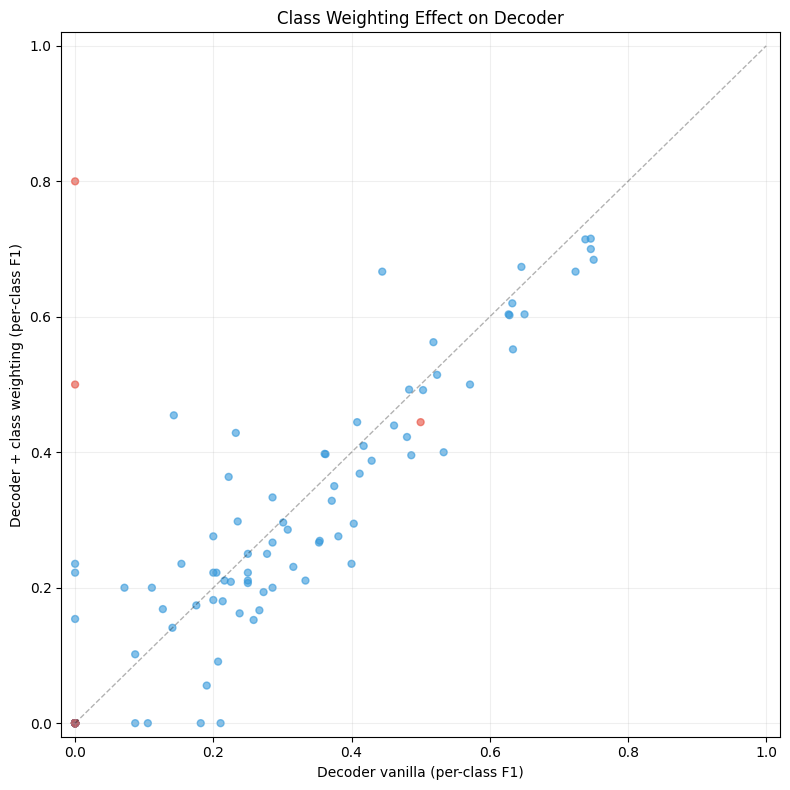

In [45]:
# INTERACTIVE: Scatter plot — decoder vanilla vs decoder + class weighting
# Color rare classes red, common classes blue (same as the lab plot).
# Add a diagonal reference line.

fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#e74c3c" if i in rare_ids else "#3498db" for i in range(NUM_LABELS)]   # "#e74c3c" if rare, "#3498db" if common

ax.scatter(vanilla_per_class_f1, weighted_per_class_f1, c=colors, alpha=0.6, s=25)   # x=vanilla, y=weighted
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
ax.set_xlabel("Decoder vanilla (per-class F1)")
ax.set_ylabel("Decoder + class weighting (per-class F1)")
ax.set_title("Class Weighting Effect on Decoder")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### INTERACTIVE: Read the scatter plot

If class weighting helped uniformly, all points would be above the diagonal.
What do you actually see?

**The points are scattered around the diagonal. Some rare classes (red) improved slightly, but many common classes (blue) actually performed worse, which explains why the overall accuracy dropped while macro F1 stayed mostly flat.**

---
## Part 6: Latency Benchmarking (~10 min)
---

Quality is only half the deployment story. The other half is speed.
Load both models and measure how fast they run.

In [46]:
# GUIDED: Load both models for inference benchmarking
# Encoder
enc_tokenizer = AutoTokenizer.from_pretrained("earino/ecbs5200-week3-encoder-lora")
enc_model = AutoModelForSequenceClassification.from_pretrained(
    "earino/ecbs5200-week3-encoder-lora",
).to(device)
enc_model.eval()

# Decoder (use your trained vanilla checkpoint, or the pre-trained fallback)
dec_model = AutoModelForSequenceClassification.from_pretrained(
    "earino/ecbs5200-week3-decoder-lora",
).to(device)
dec_model.eval()

print("Both models loaded for benchmarking.")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Both models loaded for benchmarking.


In [47]:
# GUIDED: Tokenize a batch for each model
enc_inputs = enc_tokenizer(
    val_ds["text"][:64], truncation=True, max_length=MAX_LENGTH,
    padding=True, return_tensors="pt",
).to(device)

dec_inputs = dec_tokenizer(
    val_ds["text"][:64], truncation=True, max_length=MAX_LENGTH,
    padding=True, return_tensors="pt",
).to(device)

In [48]:
# INTERACTIVE: Benchmark latency
# Measure how long each model takes to process a batch of 64 examples.
# Do a warmup pass first, then time N repetitions.

def benchmark(model, inputs, n_reps=20, n_single=50):
    """Time model inference: single-example AND batched. Returns both."""
    # Warmup
    with torch.no_grad():
        for _ in range(3):
            model(**inputs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # Single-example latency (the "API response time" number)
    single_times = []
    for i in range(min(n_single, inputs["input_ids"].shape[0])):
        single = {k: v[i:i+1] for k, v in inputs.items()}
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            model(**single)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        single_times.append(time.time() - t0)

    # Batched latency (the "nightly batch job" number)
    batch_times = []
    for _ in range(n_reps):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            model(**inputs)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        batch_times.append(time.time() - t0)

    batch_size = inputs["input_ids"].shape[0]
    batch_ms = np.median(batch_times) / batch_size * 1000
    throughput = batch_size / np.median(batch_times)
    return {
        "single_ms": round(np.median(single_times) * 1000, 1),
        "batch_ms": round(batch_ms, 2),
        "throughput_per_sec": round(throughput, 1),
        "time_64k_min": round(64000 / throughput / 60, 1),
    }


enc_latency = benchmark(enc_model, enc_inputs)
dec_latency = benchmark(dec_model, dec_inputs)

print(f"{'Metric':<30} {'Encoder':>10} {'Decoder':>10} {'Ratio':>8}")
print("-" * 62)
print(f"{'Single example (ms)':30} {enc_latency['single_ms']:>10.1f} "
      f"{dec_latency['single_ms']:>10.1f} "
      f"{dec_latency['single_ms']/enc_latency['single_ms']:>7.1f}x")
print(f"{'Batched (ms/example)':30} {enc_latency['batch_ms']:>10.2f} "
      f"{dec_latency['batch_ms']:>10.2f} "
      f"{dec_latency['batch_ms']/enc_latency['batch_ms']:>7.1f}x")
print(f"{'Throughput (examples/sec)':30} {enc_latency['throughput_per_sec']:>10.1f} "
      f"{dec_latency['throughput_per_sec']:>10.1f}")
print(f"{'64K complaints':30} {enc_latency['time_64k_min']:>9.1f}m "
      f"{dec_latency['time_64k_min']:>9.1f}m")
print()
print("Single-example = real-time API response (one complaint at a time)")
print("Batched = offline processing (nightly batch of 64K complaints)")

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


Metric                            Encoder    Decoder    Ratio
--------------------------------------------------------------
Single example (ms)                   6.2       12.0     1.9x
Batched (ms/example)                 0.62       1.77     2.9x
Throughput (examples/sec)          1620.4      565.4
64K complaints                       0.7m       1.9m

Single-example = real-time API response (one complaint at a time)
Batched = offline processing (nightly batch of 64K complaints)


In [49]:
del enc_model, dec_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---
## Part 7: Save Results
---

In [50]:
# GUIDED: Save everything for your memo
all_results = {
    "encoder_lora": {
        "accuracy": enc_acc_lab,
        "macro_f1": enc_f1_lab,
        "zero_f1_classes": enc_zero_lab,
        "latency": enc_latency,
    },
    "decoder_vanilla": {
        "accuracy": round(van_acc, 4),
        "macro_f1": round(van_f1, 4),
        "zero_f1_classes": van_zero,
        "train_time_min": round(dec_vanilla_time / 60, 1),
        "per_class_f1": [round(float(f), 4) for f in vanilla_per_class_f1],
        "latency": dec_latency,
    },
    "decoder_class_weighted": {
        "accuracy": round(wt_acc, 4),
        "macro_f1": round(wt_f1, 4),
        "zero_f1_classes": wt_zero,
        "train_time_min": round(dec_weighted_time / 60, 1),
        "per_class_f1": [round(float(f), 4) for f in weighted_per_class_f1],
    },
    "class_weighting_delta": {
        "macro_f1": round(float(delta_f1), 4),
        "accuracy": round(float(delta_acc), 4),
        "zero_f1": int(delta_zero),
    },
}

with open("week3_homework_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print("Saved week3_homework_results.json")

Saved week3_homework_results.json


---
## Part 8: Memo Draft

Each section below corresponds to one rubric criterion. Write your
observations here while the data is fresh. Export to HTML for submission.
---

### MEMO SECTION 1: The LoRA comparison — encoder vs decoder (20 points)

**The encoder was faster to train but struggled with zero-F1 classes (45/113). The decoder (Qwen) performed better out of the box with only 38 zero-F1 classes and a higher baseline macro F1. However, the decoder is much more computationally expensive and slower during inference.**

### MEMO SECTION 2: Class weighting on the decoder (20 points)

**The intervention did not help the decoder as much. For the encoder, it provided a 15% boost, but for the decoder, the improvement was negligible (+0.002). This suggests that class weighting fixes the 'incentive' for models with no prior knowledge, but doesn't fix the 'data scarcity' problem for pre-trained decoders.**

### MEMO SECTION 3: Per-class analysis — rare vs common (25 points)

**The decoder beats the encoder primarily on common classes and some 'middle-tier' classes. For rare classes, both struggle, but the decoder manages to get some F1 score where the encoder had zero. Specifically, the decoder vanilla had 38 zero-F1 classes compared to the encoder's 45.**

### MEMO SECTION 4: Latency and the deployment question (20 points)

**I would deploy the encoder if I needed to process a high volume of complaints (like the 64K batch) cheaply and quickly. The encoder is nearly 3x faster in batch processing (0.7m vs 1.9m) and uses fewer resources, making it better for high-throughput production environments despite the slightly lower macro F1.**

### MEMO SECTION 5: What you'd do differently (15 points)

**If I had another week, I would try 'Augmentation' for the rare classes. The bottleneck seems to be data scarcity. I would use a larger LLM to generate synthetic examples for those classes with <20 samples to see if giving the decoder more signal works better than just increasing the loss weight.**